# Project 2: Data Classification Using AI

| Detail | Info |
|---|---|
| **Name** | [Muhammad Anas Dev] |
| **Course/Batch** | DecodeLabs Industrial Training Kit — 2026 |
| **Dataset** | Iris Dataset (150 samples, 3 classes) |
| **Algorithm Used** | K-Nearest Neighbors (KNN) |
| **Goal** | Build a supervised classification model to predict iris flower species based on sepal and petal measurements |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(y, iris.target_names)

print(df.shape)
print(df["species"].value_counts())
df.head()

(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(120, 4) (30, 4)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling (first row):", X_train[0])
print("After scaling (first row):", X_train_scaled[0])

Before scaling (first row): [4.4 2.9 1.4 0.2]
After scaling (first row): [-1.72156775 -0.33210111 -1.34572231 -1.32327558]


In [ ]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

print("Predictions:", predictions)
print("Actual:     ", y_test)

Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="weighted")
cm = confusion_matrix(y_test, predictions)

print("Accuracy:", acc)
print("F1 Score:", f1)
print(cm)
print(classification_report(y_test, predictions, target_names=iris.target_names))

Accuracy: 0.9333333333333333
F1 Score: 0.9326599326599326
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



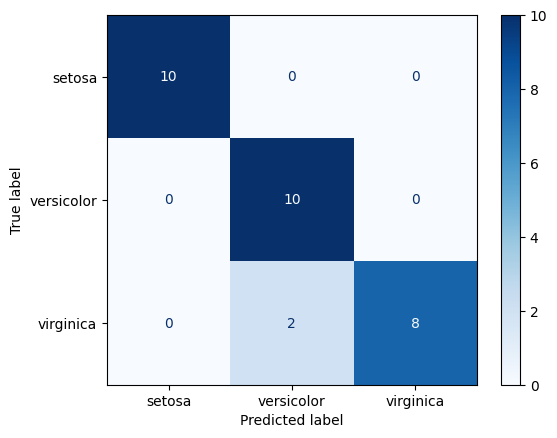

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.show()

## Final Results Summary

| Metric | Value |
|---|---|
| **Accuracy** | 93.33% |
| **F1 Score** | 0.933 |
| **Algorithm Used** | K-Nearest Neighbors (K=5) |
| **Train/Test Split** | 80% / 20% |
| **Total Samples** | 150 (120 train, 30 test) |

### Conclusion
The KNN model successfully classified iris flowers into three species (Setosa, Versicolor, Virginica) with high accuracy. Setosa was classified perfectly (100%), while a small overlap was observed between Versicolor and Virginica due to similar petal measurements — a common and expected challenge in real-world classification tasks.